<a href="https://colab.research.google.com/github/mvuddandi/Capstone_PatchTST/blob/main/Features_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! git clone https://github.com/mvuddandi/Capstone_PatchTST.git

Cloning into 'Capstone_PatchTST'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 42 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 8.11 MiB | 4.95 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [2]:
%cd /content/Capstone_PatchTST


/content/Capstone_PatchTST


In [3]:
import pandas as pd
df = pd.read_csv("/content/Capstone_PatchTST/weather.csv")

In [4]:
df.columns

Index(['date', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)', 'rain (mm)', 'raining (s)', 'SWDR (W/m�)',
       'PAR (�mol/m�/s)', 'max. PAR (�mol/m�/s)', 'Tlog (degC)', 'OT'],
      dtype='object')

In [5]:
import numpy as np
import pandas as pd

target = "T (degC)"   # change this to any column you want

df_num = df.select_dtypes(include=[np.number]).copy()
df_num = df_num.replace([np.inf, -np.inf], np.nan).dropna()

pearson = df_num.corr(method="pearson")[target].sort_values(
    key=lambda s: s.abs(), ascending=False
)
spearman = df_num.corr(method="spearman")[target].sort_values(
    key=lambda s: s.abs(), ascending=False
)

result = pd.DataFrame({
    "pearson_corr": pearson,
    "spearman_corr": spearman
})

result


,pearson_corr,spearman_corr
H2OC (mmol/mol),0.761934,0.808874
OT,-0.039150,-0.554148
PAR (�mol/m�/s),0.459806,0.415097
SWDR (W/m�),0.448607,0.401805
T (degC),1.000000,1.000000
Tdew (degC),0.782740,0.809700
Tlog (degC),0.981562,0.983058
Tpot (K),0.995228,0.994495
VPact (mbar),0.762860,0.809700
VPdef (mbar),0.779616,0.730476


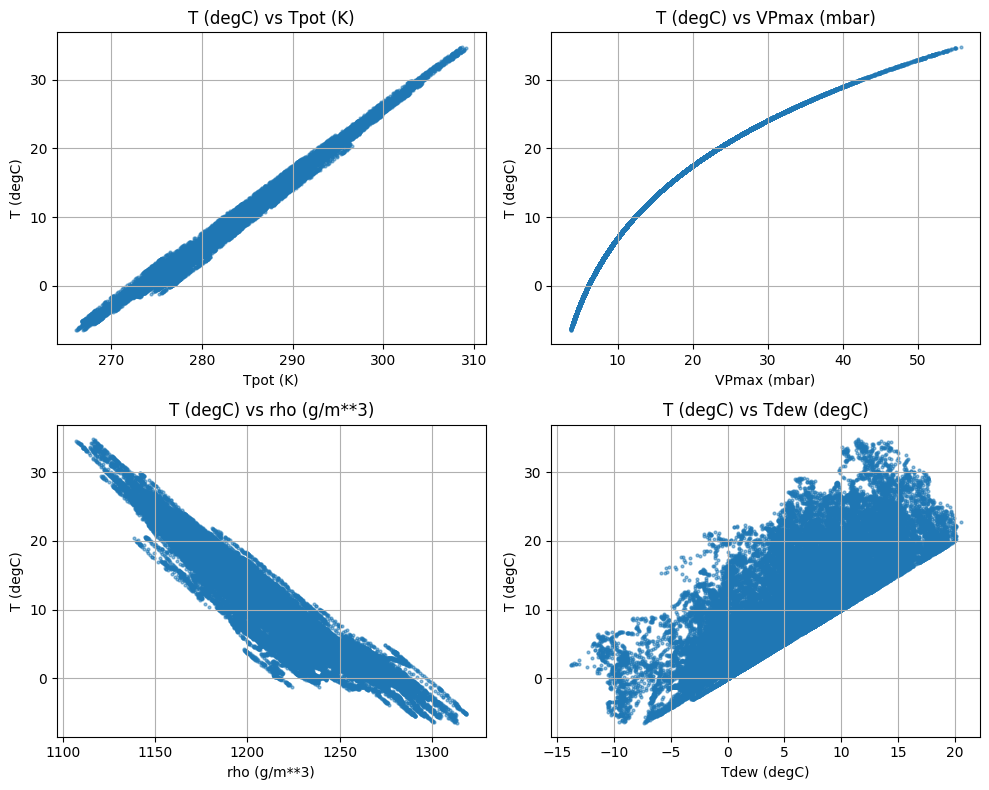

In [6]:
import matplotlib.pyplot as plt

target = "T (degC)"

top_features = [
    "Tpot (K)",
    "VPmax (mbar)",
    "rho (g/m**3)",
    "Tdew (degC)"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df[target], s=4, alpha=0.5)
    ax.set_xlabel(feat)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {feat}")
    ax.grid(True)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import pandas as pd

# 1) Keep only numeric columns
df_num = df.select_dtypes(include=[np.number]).copy()

# Clean inf / NaN
df_num = df_num.replace([np.inf, -np.inf], np.nan).dropna()

# 2) Initialize empty matrices
pearson_matrix  = pd.DataFrame(index=df_num.columns, columns=df_num.columns, dtype=float)
spearman_matrix = pd.DataFrame(index=df_num.columns, columns=df_num.columns, dtype=float)

# 3) Loop over all variable pairs
for col_i in df_num.columns:
    for col_j in df_num.columns:
        pearson_matrix.loc[col_i, col_j] = df_num[col_i].corr(df_num[col_j], method="pearson")
        spearman_matrix.loc[col_i, col_j] = df_num[col_i].corr(df_num[col_j], method="spearman")

# 4) Output
pearson_matrix, spearman_matrix


(                      p (mbar)  T (degC)  Tpot (K)  Tdew (degC)    rh (%)  \
 p (mbar)              1.000000 -0.127305 -0.223450    -0.207280 -0.068386   
 T (degC)             -0.127305  1.000000  0.995228     0.782740 -0.540784   
 Tpot (K)             -0.223450  0.995228  1.000000     0.789478 -0.524880   
 Tdew (degC)          -0.207280  0.782740  0.789478     1.000000  0.087203   
 rh (%)               -0.068386 -0.540784 -0.524880     0.087203  1.000000   
 VPmax (mbar)         -0.098905  0.967901  0.961013     0.712665 -0.561612   
 VPact (mbar)         -0.183765  0.762860  0.767773     0.977413  0.085528   
 VPdef (mbar)         -0.002805  0.779616  0.766556     0.272064 -0.836007   
 sh (g/kg)            -0.200955  0.761550  0.768193     0.976878  0.086812   
 H2OC (mmol/mol)      -0.201174  0.761934  0.768590     0.977256  0.086729   
 rho (g/m**3)          0.437434 -0.946510 -0.973132    -0.798148  0.440074   
 wv (m/s)             -0.010172  0.007514  0.008397     0.000130

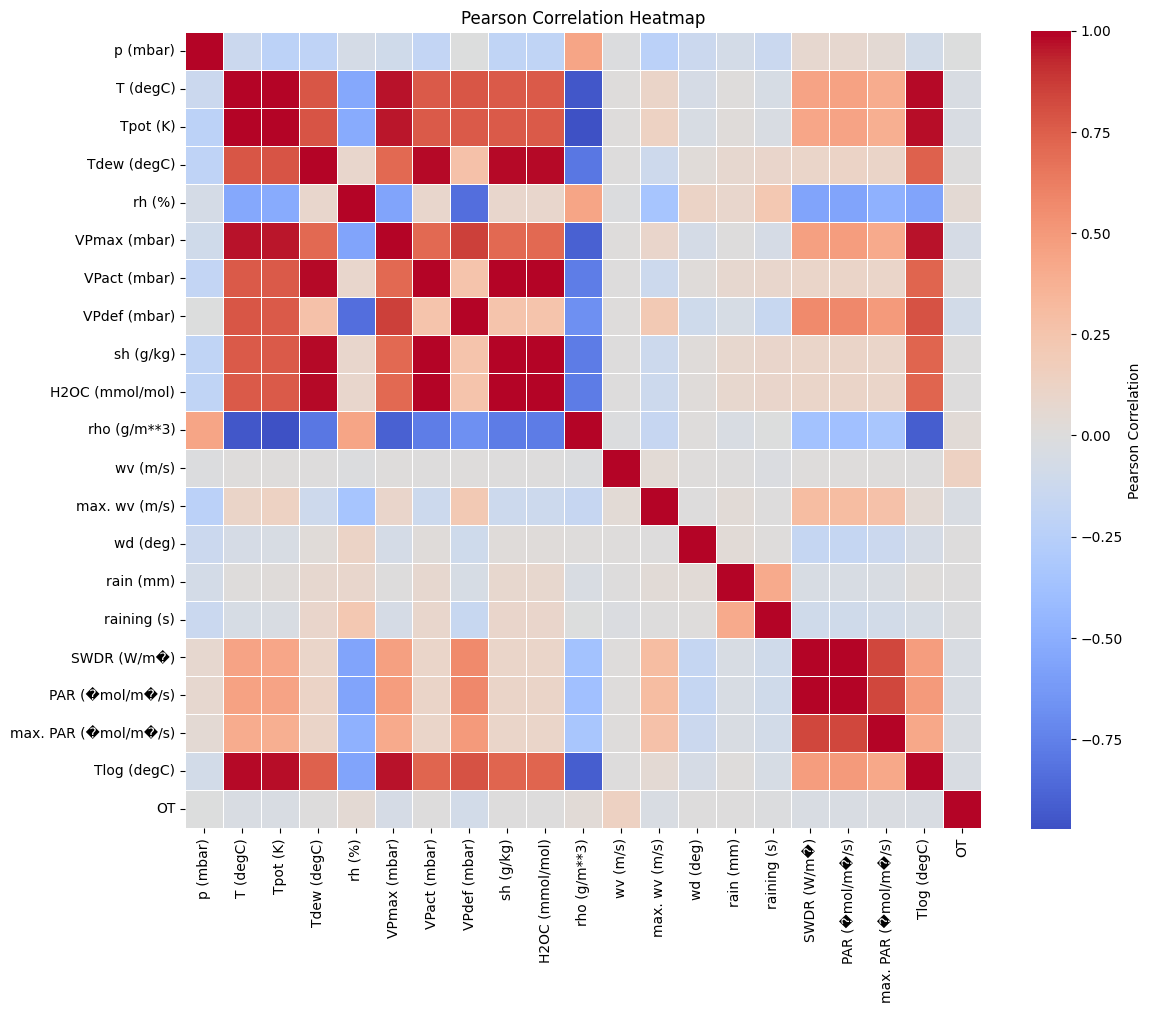

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(
    pearson_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"}
)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()


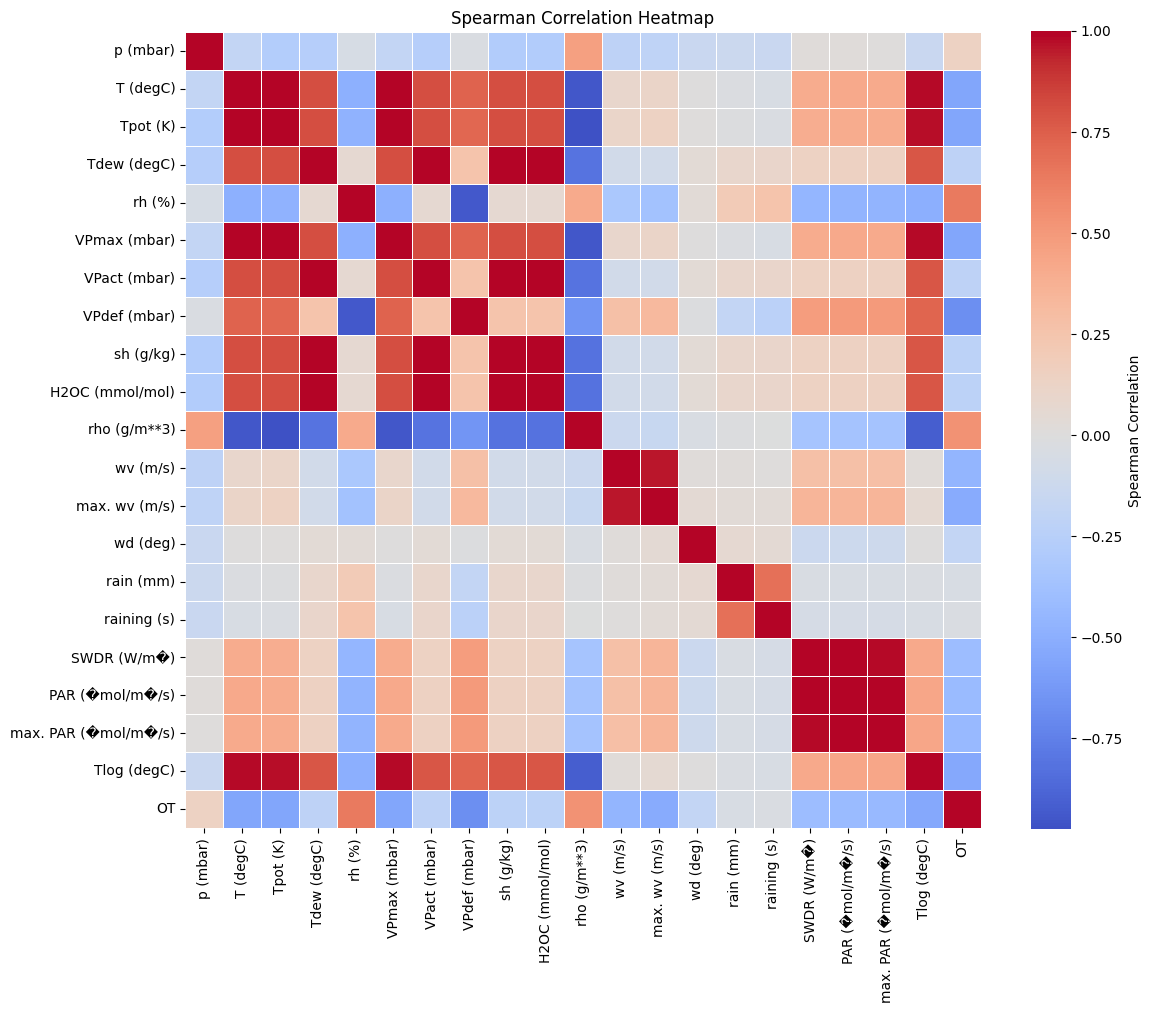

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    spearman_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman Correlation"}
)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()


In [16]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# =========================
# CONFIG
# =========================
TARGET = "T (degC)"
HORIZON = 1          # predict t+1
N_SPLITS = 5         # walk-forward CV folds

# =========================
# 0) Clean numeric dataframe
# =========================
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()

# numeric columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if TARGET not in df_clean.columns:
    raise ValueError(f"TARGET '{TARGET}' not found in df columns.")

# =========================
# 1) Helper: robust column matching for weird encodings
# =========================
def find_col_contains(df_cols, substrings):
    """
    Returns the first column name that contains ALL substrings (case-insensitive).
    """
    cols = list(df_cols)
    for col in cols:
        s = col.lower()
        if all(sub.lower() in s for sub in substrings):
            return col
    return None

# Try to locate radiation columns even if they are garbled
COL_SWDR = find_col_contains(df_clean.columns, ["swdr"])
COL_PAR  = find_col_contains(df_clean.columns, ["par ("])
# If PAR pattern fails, fallback to any col containing 'par' but not 'max'
if COL_PAR is None:
    for c in df_clean.columns:
        if "par" in c.lower() and "max" not in c.lower():
            COL_PAR = c
            break

# =========================
# 2) Feature sets
# =========================
FEATURES_FULL = [c for c in num_cols if c != TARGET]

FEATURES_REDUCED = [
    "p (mbar)",
    "Tdew (degC)",
    "sh (g/kg)",          # or "H2OC (mmol/mol)"
    "wv (m/s)",
    "rain (mm)"
]

# add radiation columns if found
if COL_SWDR is not None:
    FEATURES_REDUCED.append(COL_SWDR)
if COL_PAR is not None:
    FEATURES_REDUCED.append(COL_PAR)

# keep only existing numeric cols
FEATURES_REDUCED = [c for c in FEATURES_REDUCED if c in df_clean.columns and c in num_cols]

# quick sanity checks
if len(FEATURES_FULL) == 0:
    raise ValueError("No FEATURES_FULL found (check numeric columns).")
if len(FEATURES_REDUCED) == 0:
    raise ValueError("No FEATURES_REDUCED found after filtering. Check column names.")

print("TARGET:", TARGET)
print("FULL features:", len(FEATURES_FULL))
print("REDUCED features:", len(FEATURES_REDUCED))
print("REDUCED list:", FEATURES_REDUCED)

# =========================
# 3) Build supervised dataset (t -> t+horizon)
# =========================
def make_supervised(data, features, target, horizon=1):
    d = data.copy()
    d["y"] = d[target].shift(-horizon)
    d = d.dropna()
    X = d[features]
    y = d["y"]
    return X, y

X_full, y_full = make_supervised(df_clean, FEATURES_FULL, TARGET, HORIZON)
X_red,  y_red  = make_supervised(df_clean, FEATURES_REDUCED, TARGET, HORIZON)

# align indices just in case
common_idx = X_full.index.intersection(X_red.index).intersection(y_full.index).intersection(y_red.index)
X_full = X_full.loc[common_idx]
y_full = y_full.loc[common_idx]
X_red  = X_red.loc[common_idx]
y_red  = y_red.loc[common_idx]

# =========================
# 4) Walk-forward CV evaluation
# =========================
def evaluate_timeseries_cv(X, y, model, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    for fold, (tr, te) in enumerate(tscv.split(X), 1):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]

        model.fit(Xtr, ytr)
        pred = model.predict(Xte)

        rmse = np.sqrt(mean_squared_error(yte, pred))
        mae  = mean_absolute_error(yte, pred)

        rows.append({"fold": fold, "rmse": rmse, "mae": mae})
    return pd.DataFrame(rows)

model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

res_full = evaluate_timeseries_cv(X_full, y_full, model, n_splits=N_SPLITS)
res_red  = evaluate_timeseries_cv(X_red,  y_red,  model, n_splits=N_SPLITS)

# =========================
# 5) Summary + deltas
# =========================
summary = pd.DataFrame({
    "set": ["FULL", "REDUCED"],
    "rmse_mean": [res_full["rmse"].mean(), res_red["rmse"].mean()],
    "rmse_std":  [res_full["rmse"].std(),  res_red["rmse"].std()],
    "mae_mean":  [res_full["mae"].mean(),  res_red["mae"].mean()],
    "mae_std":   [res_full["mae"].std(),   res_red["mae"].std()],
})

delta_rmse_pct = (summary.loc[1, "rmse_mean"] - summary.loc[0, "rmse_mean"]) / summary.loc[0, "rmse_mean"] * 100
delta_mae_pct  = (summary.loc[1, "mae_mean"]  - summary.loc[0, "mae_mean"])  / summary.loc[0, "mae_mean"]  * 100

print("\n=== SUMMARY ===")
print(summary)

print("\n=== DELTAS (REDUCED vs FULL) ===")
print("delta_rmse_pct:", delta_rmse_pct)
print("delta_mae_pct :", delta_mae_pct)


TARGET: T (degC)
FULL features: 20
REDUCED features: 7
REDUCED list: ['p (mbar)', 'Tdew (degC)', 'sh (g/kg)', 'wv (m/s)', 'rain (mm)', 'SWDR (W/m�)', 'PAR (�mol/m�/s)']

=== SUMMARY ===
       set  rmse_mean  rmse_std  mae_mean   mae_std
0     FULL   0.587088  0.365419  0.288856  0.142923
1  REDUCED   5.051383  0.509003  4.001345  0.344125

=== DELTAS (REDUCED vs FULL) ===
delta_rmse_pct: 760.4125907773275
delta_mae_pct : 1285.2378957146273
